# HAM10000 — Evaluación de calidad de imágenes sintéticas

Evalúa cuatro fuentes de imágenes sintéticas de melanoma respecto a la distribución real.

| Fuente | N | Resolución | Método |
|---|---|---|---|
| `real_mel` | 801 | variable | Referencia HAM10000 |
| `textual_inversion` | 4500 | 512×512 | SD TI token `<mel-skin>` |
| `img2img` | 2403 | 512×512 | SD img2img variaciones de reales |
| `gan_64` | 1000 | 64×64 | WGAN-GP (Gabriel) |
| `gan_640` | 4000 | 640×480 | GAN alternativo (Gabriel) |

**Métricas:**
- **FID** (Fréchet Inception Distance): distancia entre distribuciones real y sintética — menor es mejor
- **IS** (Inception Score): calidad y diversidad de las sintéticas — mayor es mejor
- **Filtro calidad**: % de imágenes que pasan un filtro de calidad visual mínima
- **Grillas visuales**: inspección manual de muestras aleatorias

⚠️ FID usa features de InceptionV3 (ImageNet). Para imágenes dermoscópicas los valores absolutos
deben interpretarse comparativamente entre fuentes, no como valores absolutos.

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = DEVICE.type == 'cuda'
print(f'IN_COLAB={IN_COLAB}  device={DEVICE}')

IN_COLAB=False  device=cuda


In [2]:
from pathlib import Path

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/ham10000-augmentation')
    PROJECT_ROOT = DRIVE_ROOT
    SYNTH_ROOT   = DRIVE_ROOT / 'synthetic'
    GAN_ZIP      = None  # debe estar en Drive como gan_generated.zip
else:
    PROJECT_ROOT = Path.cwd()
    SYNTH_ROOT   = PROJECT_ROOT / 'data/synthetic'
    GAN_ZIP      = next(PROJECT_ROOT.glob('gan_generated*.zip'), None)

SPLITS_DIR   = PROJECT_ROOT / 'data/processed/splits'
IMAGES_DIR   = PROJECT_ROOT / 'data/processed/images'
EVAL_OUT     = PROJECT_ROOT / 'reports/quality_evaluation'
EVAL_OUT.mkdir(parents=True, exist_ok=True)

print(f'Sintéticas: {SYNTH_ROOT}')
print(f'GAN ZIP:    {GAN_ZIP}')
print(f'Salida:     {EVAL_OUT}')

Sintéticas: /home/schica/proyecto-imagenes-y-vision/data/synthetic
GAN ZIP:    /home/schica/proyecto-imagenes-y-vision/gan_generated-20260515T151145Z-3-001.zip
Salida:     /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation


In [3]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import torch_fidelity; print(f'torch_fidelity ok')
except ImportError:
    pip_install('torch-fidelity'); import torch_fidelity

try:
    import cv2; print(f'cv2 ok')
except ImportError:
    pip_install('opencv-python-headless'); import cv2

try:
    import pandas as pd; print(f'pandas ok')
except ImportError:
    pip_install('pandas'); import pandas as pd

import numpy as np
import json, random, shutil, zipfile
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
print('Dependencias listas')

torch_fidelity ok
cv2 ok


pandas ok


Dependencias listas


## Estado de la evaluación
Ejecuta esta celda para ver qué bloques ya están completos.

In [4]:
MARKERS = {
    'GAN extraído':      EVAL_OUT / 'gan_extracted.json',
    'Ref real copiada':  EVAL_OUT / 'real_ref_ready.json',
    'FID/IS completo':   EVAL_OUT / 'fid_results.json',
    'Filtro calidad':    EVAL_OUT / 'quality_filter.json',
    'Grillas visuales':  EVAL_OUT / 'grids_done.txt',
}

for name, path in MARKERS.items():
    status = '✅' if path.exists() else '⬜'
    print(f'  {status} {name}')

  ⬜ GAN extraído
  ⬜ Ref real copiada
  ⬜ FID/IS completo
  ⬜ Filtro calidad
  ⬜ Grillas visuales


## Paso 1 — Preparar directorios de imágenes

In [5]:
# --- Extraer GAN ZIP ---
gan_marker = EVAL_OUT / 'gan_extracted.json'

GAN_64_DIR  = PROJECT_ROOT / 'data/synthetic/gan_64'
GAN_640_DIR = PROJECT_ROOT / 'data/synthetic/gan_640'

if gan_marker.exists():
    info = json.loads(gan_marker.read_text())
    print(f'GAN ya extraído — gan_64: {info["gan_64"]}  gan_640: {info["gan_640"]}')
else:
    assert GAN_ZIP and GAN_ZIP.exists(), f'ZIP del GAN no encontrado en {GAN_ZIP}'
    GAN_64_DIR.mkdir(parents=True, exist_ok=True)
    GAN_640_DIR.mkdir(parents=True, exist_ok=True)

    print('Extrayendo GAN ZIP...')
    import struct
    with zipfile.ZipFile(GAN_ZIP) as zf:
        for member in zf.infolist():
            if not member.filename.endswith('.png'):
                continue
            data = zf.read(member.filename)
            # Leer dimensiones del PNG sin descomprimir completo
            w = struct.unpack('>I', data[16:20])[0]
            h = struct.unpack('>I', data[20:24])[0]
            fname = Path(member.filename).name
            if w == 64 and h == 64:
                (GAN_64_DIR / fname).write_bytes(data)
            else:
                (GAN_640_DIR / fname).write_bytes(data)

    n64  = len(list(GAN_64_DIR.glob('*.png')))
    n640 = len(list(GAN_640_DIR.glob('*.png')))
    info = {'gan_64': n64, 'gan_640': n640}
    gan_marker.write_text(json.dumps(info, indent=2))
    print(f'Listo — gan_64: {n64}  gan_640: {n640}')

Extrayendo GAN ZIP...


Listo — gan_64: 1000  gan_640: 4000


In [6]:
# --- Preparar directorio de referencia real (solo mel de train) ---
ref_marker = EVAL_OUT / 'real_ref_ready.json'
REAL_MEL_DIR = PROJECT_ROOT / 'data/synthetic/real_mel_ref'

if ref_marker.exists():
    info = json.loads(ref_marker.read_text())
    print(f'Referencia real ya preparada — {info["count"]} imágenes')
else:
    REAL_MEL_DIR.mkdir(parents=True, exist_ok=True)
    train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
    mel_paths = [
        PROJECT_ROOT / row['image_path']
        for _, row in train_df[train_df['label'] == 1].iterrows()
    ]
    print(f'Copiando {len(mel_paths)} imágenes de melanoma real...')
    for p in mel_paths:
        shutil.copy2(p, REAL_MEL_DIR / p.name)
    info = {'count': len(mel_paths)}
    ref_marker.write_text(json.dumps(info, indent=2))
    print(f'Listo — {len(mel_paths)} imágenes en {REAL_MEL_DIR}')

Copiando 801 imágenes de melanoma real...


Listo — 801 imágenes en /home/schica/proyecto-imagenes-y-vision/data/synthetic/real_mel_ref


## Paso 2 — FID e IS por fuente

FID mide la distancia entre la distribución de features Inception de las imágenes reales
y las sintéticas. IS mide calidad y diversidad de las sintéticas.

Este bloque tarda ~5–10 min por fuente en CPU.

In [7]:
from torch_fidelity import calculate_metrics

fid_marker = EVAL_OUT / 'fid_results.json'

SOURCES = {
    'textual_inversion': SYNTH_ROOT / 'textual_inversion',
    'img2img':           SYNTH_ROOT / 'img2img',
    'gan_64':            GAN_64_DIR,
    'gan_640':           GAN_640_DIR,
}

if fid_marker.exists():
    fid_results = json.loads(fid_marker.read_text())
    print('FID/IS ya calculados:')
    for src, m in fid_results.items():
        print(f'  {src:25s}  FID={m["fid"]:.1f}  IS={m["is_mean"]:.3f}±{m["is_std"]:.3f}')
else:
    fid_results = {}
    for name, src_dir in SOURCES.items():
        if not src_dir.exists():
            print(f'  {name}: directorio no encontrado ({src_dir}) — omitido')
            continue
        n = len(list(src_dir.glob('*.*')))
        if n < 10:
            print(f'  {name}: muy pocas imágenes ({n}) — omitido')
            continue
        print(f'Calculando FID/IS para {name} ({n} imágenes)...')
        try:
            m = calculate_metrics(
                input1=str(REAL_MEL_DIR),
                input2=str(src_dir),
                cuda=False,
                fid=True,
                isc=True,
                verbose=False,
            )
            fid_results[name] = {
                'fid':     round(m['frechet_inception_distance'], 2),
                'is_mean': round(m['inception_score_mean'], 4),
                'is_std':  round(m['inception_score_std'], 4),
                'n_synth': n,
            }
            print(f'  → FID={fid_results[name]["fid"]:.1f}  IS={fid_results[name]["is_mean"]:.3f}±{fid_results[name]["is_std"]:.3f}')
        except Exception as e:
            print(f'  ERROR en {name}: {e}')
            fid_results[name] = {'error': str(e)}

    fid_marker.write_text(json.dumps(fid_results, indent=2))
    print('\nGuardado en', fid_marker)

Calculando FID/IS para textual_inversion (4500 imágenes)...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/schica/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth


/home/schica/anaconda3/envs/ham10000-augmentation/lib/python3.11/site-packages/torch/cuda/__init__.py:371: UserWarning: Found GPU0 NVIDIA GeForce GTX 1050 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/schica/anaconda3/envs/ham10000-augmentation/lib/python3.11/site-packages/torch/cuda/__init__.py:489: UserWarning: 
NVIDIA GeForce GTX 1050 with CUDA capability sm_61 is not compatibl

  ERROR en textual_inversion: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Calculando FID/IS para img2img (2403 imágenes)...


  ERROR en img2img: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Calculando FID/IS para gan_64 (1000 imágenes)...


  ERROR en gan_64: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Calculando FID/IS para gan_640 (4000 imágenes)...


  ERROR en gan_640: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Guardado en /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/fid_results.json


## Paso 3 — Filtro de calidad visual

Detecta imágenes que probablemente son artefactos o generaciones fallidas usando:
- **Brillo**: descarta imágenes demasiado oscuras o quemadas
- **Contraste**: descarta imágenes sin variación (color sólido, ruido uniforme)
- **Tono piel**: verifica presencia mínima de tonos piel/lesión en HSV

In [8]:
filter_marker = EVAL_OUT / 'quality_filter.json'

def quality_score(img_path: Path, size: int = 224):
    """
    Devuelve (passes: bool, stats: dict) para una imagen.
    Criterios:
      - mean_v: brillo medio en V (HSV) — fuera de [20, 235] → falla
      - std_rgb: desv. estándar media RGB — < 8 → imagen muy uniforme → falla
      - skin_ratio: % pixels con H en rango piel/lesión [0-30] o [150-180] — < 2% → falla
    """
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((size, size)))
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

        mean_v  = float(hsv[:, :, 2].mean())
        std_rgb = float(img.std(axis=(0, 1)).mean())

        h = hsv[:, :, 0]
        s = hsv[:, :, 1]
        v = hsv[:, :, 2]
        # Tonos piel (rosa/marrón) y lesión (rojo oscuro, negro) con saturación mínima
        skin_mask = ((h <= 25) | (h >= 150)) & (s > 20) & (v > 20)
        skin_ratio = float(skin_mask.mean())

        passes = (20 < mean_v < 235) and (std_rgb >= 8) and (skin_ratio >= 0.02)
        return passes, {'mean_v': round(mean_v, 1), 'std_rgb': round(std_rgb, 2),
                        'skin_ratio': round(skin_ratio, 4)}
    except Exception as e:
        return False, {'error': str(e)}


if filter_marker.exists():
    filter_results = json.loads(filter_marker.read_text())
    print('Filtro ya calculado:')
    for src, stats in filter_results.items():
        pct = stats['pass_pct']
        print(f'  {src:25s}  {stats["passed"]}/{stats["total"]} pasan ({pct:.1f}%)')
else:
    ALL_SOURCES = {
        'real_mel':           REAL_MEL_DIR,
        'textual_inversion':  SYNTH_ROOT / 'textual_inversion',
        'img2img':            SYNTH_ROOT / 'img2img',
        'gan_64':             GAN_64_DIR,
        'gan_640':            GAN_640_DIR,
    }
    filter_results = {}

    for name, src_dir in ALL_SOURCES.items():
        if not src_dir.exists():
            continue
        exts = ['*.jpg', '*.jpeg', '*.png']
        paths = [p for ext in exts for p in src_dir.glob(ext)]
        if not paths:
            continue

        # Muestra representativa (máx 500 imágenes para velocidad)
        sample = random.Random(42).sample(paths, min(500, len(paths)))
        passed = 0
        per_image_stats = []

        print(f'Filtrando {name} ({len(sample)} muestras)...')
        for p in sample:
            ok, stats = quality_score(p)
            if ok:
                passed += 1
            per_image_stats.append(stats)

        # Estadísticas agregadas (excluyendo errores)
        valid = [s for s in per_image_stats if 'error' not in s]
        agg = {}
        if valid:
            agg['mean_v_avg']     = round(float(np.mean([s['mean_v'] for s in valid])), 1)
            agg['std_rgb_avg']    = round(float(np.mean([s['std_rgb'] for s in valid])), 2)
            agg['skin_ratio_avg'] = round(float(np.mean([s['skin_ratio'] for s in valid])), 4)

        filter_results[name] = {
            'total':    len(sample),
            'passed':   passed,
            'pass_pct': round(100 * passed / len(sample), 1),
            **agg,
        }
        print(f'  → {passed}/{len(sample)} pasan ({filter_results[name]["pass_pct"]:.1f}%)')

    filter_marker.write_text(json.dumps(filter_results, indent=2))
    print('\nGuardado en', filter_marker)

Filtrando real_mel (500 muestras)...


  → 497/500 pasan (99.4%)
Filtrando textual_inversion (500 muestras)...


  → 423/500 pasan (84.6%)
Filtrando img2img (500 muestras)...


  → 498/500 pasan (99.6%)
Filtrando gan_64 (500 muestras)...


  → 490/500 pasan (98.0%)
Filtrando gan_640 (500 muestras)...


  → 424/500 pasan (84.8%)

Guardado en /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/quality_filter.json


## Paso 4 — Grillas visuales de muestras aleatorias

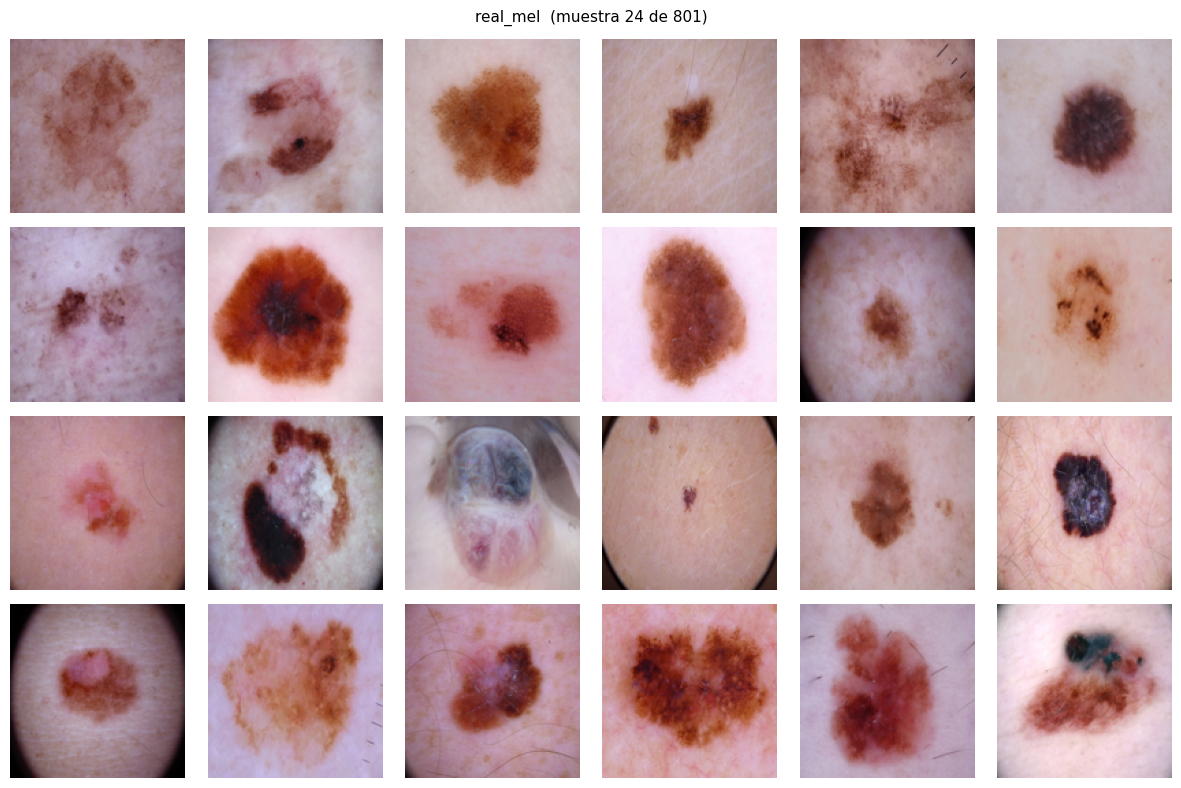

Grilla guardada: /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/grid_real_mel.png


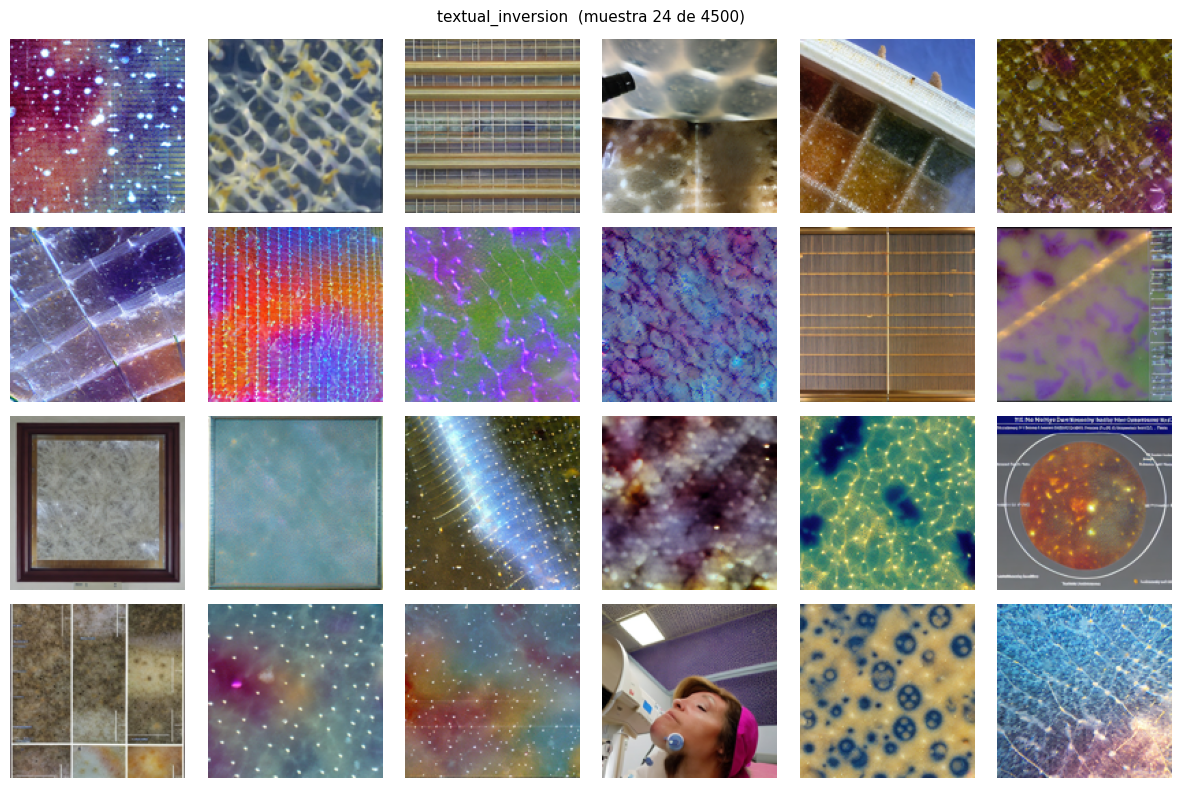

Grilla guardada: /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/grid_textual_inversion.png


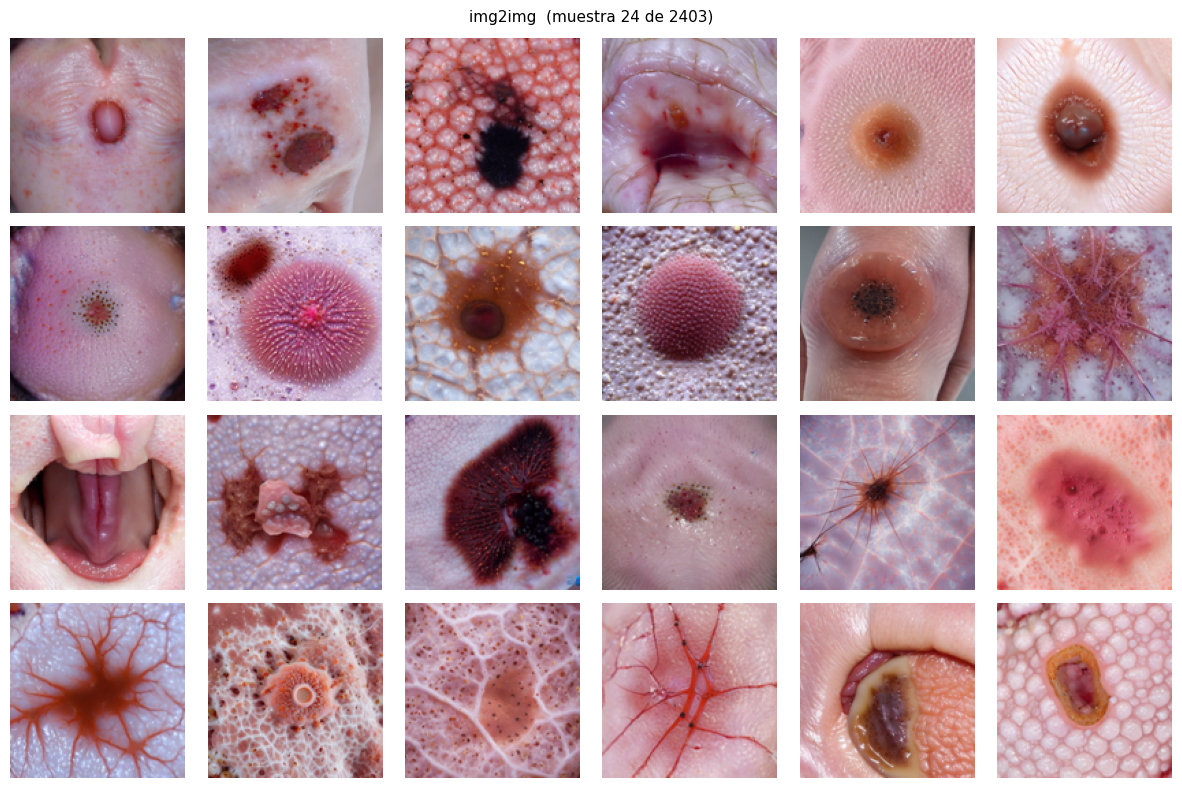

Grilla guardada: /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/grid_img2img.png


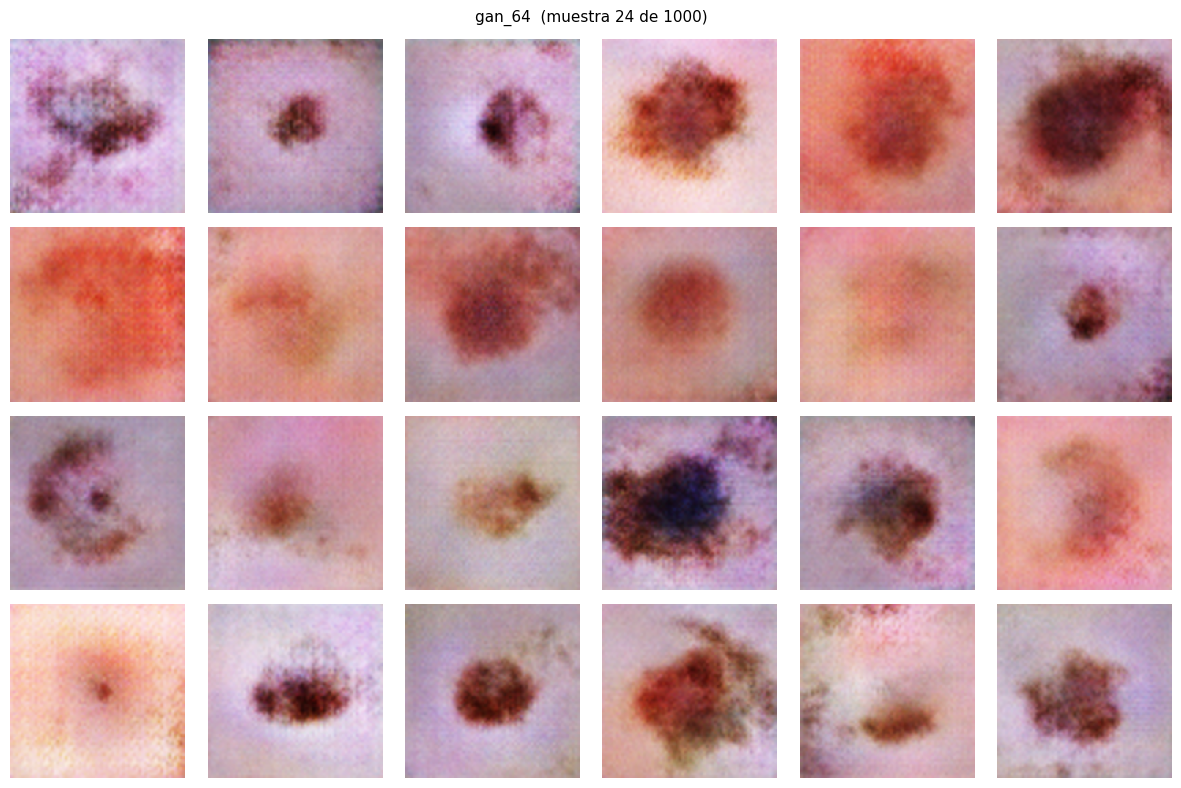

Grilla guardada: /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/grid_gan_64.png


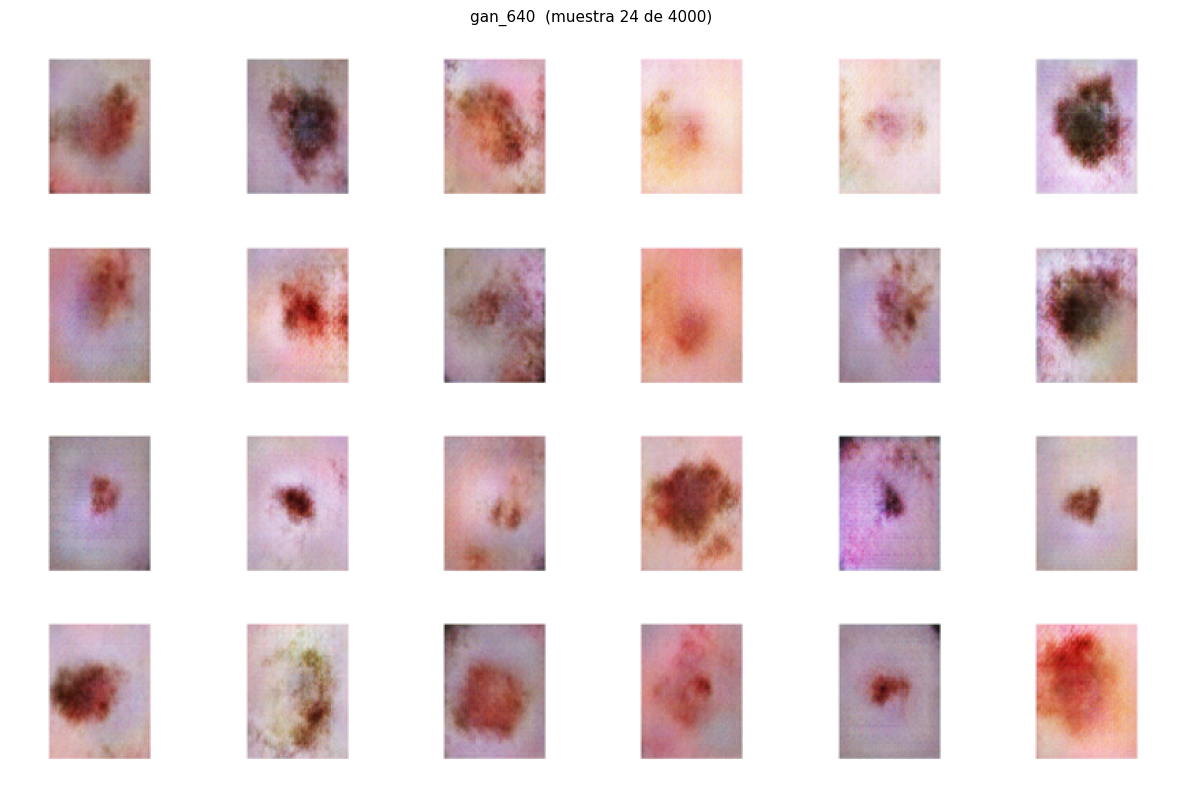

Grilla guardada: /home/schica/proyecto-imagenes-y-vision/reports/quality_evaluation/grid_gan_640.png

Todas las grillas generadas


In [9]:
grids_marker = EVAL_OUT / 'grids_done.txt'

GRID_SOURCES = {
    'real_mel':          (REAL_MEL_DIR,            ['*.jpg', '*.jpeg']),
    'textual_inversion': (SYNTH_ROOT/'textual_inversion', ['*.jpg']),
    'img2img':           (SYNTH_ROOT/'img2img',    ['*.jpg']),
    'gan_64':            (GAN_64_DIR,              ['*.png']),
    'gan_640':           (GAN_640_DIR,             ['*.png']),
}
ROWS, COLS = 4, 6

if grids_marker.exists():
    print('Grillas ya generadas en', EVAL_OUT)
else:
    for name, (src_dir, exts) in GRID_SOURCES.items():
        if not src_dir.exists():
            continue
        paths = [p for ext in exts for p in src_dir.glob(ext)]
        if not paths:
            continue
        sample = random.Random(42).sample(paths, min(ROWS * COLS, len(paths)))

        fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 2, ROWS * 2))
        for ax, p in zip(axes.flat, sample):
            img = Image.open(p).convert('RGB').resize((128, 128))
            ax.imshow(img)
            ax.axis('off')
        for ax in axes.flat[len(sample):]:
            ax.axis('off')
        fig.suptitle(f'{name}  (muestra {len(sample)} de {len(paths)})', fontsize=11)
        fig.tight_layout()
        out_path = EVAL_OUT / f'grid_{name}.png'
        fig.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'Grilla guardada: {out_path}')

    grids_marker.write_text('done')
    print('\nTodas las grillas generadas')

## Resumen — tabla comparativa y plots

In [10]:
import pandas as pd

# Combinar FID y filtro en una tabla
fid_data    = json.loads(fid_marker.read_text()) if fid_marker.exists() else {}
filter_data = json.loads(filter_marker.read_text()) if filter_marker.exists() else {}

rows = []
for src in ['textual_inversion', 'img2img', 'gan_64', 'gan_640']:
    row = {'Fuente': src}
    if src in fid_data and 'fid' in fid_data[src]:
        row['FID ↓']    = fid_data[src]['fid']
        row['IS ↑']     = fid_data[src]['is_mean']
        row['N synth']  = fid_data[src]['n_synth']
    if src in filter_data:
        row['Pasan filtro %'] = filter_data[src]['pass_pct']
        row['Skin ratio avg'] = filter_data[src].get('skin_ratio_avg', '?')
    rows.append(row)

if rows:
    df = pd.DataFrame(rows).set_index('Fuente')
    print('\n=== Resumen de calidad ===' )
    print(df.to_string())

    # Guardar tabla
    df.to_csv(EVAL_OUT / 'quality_summary.csv')

    # Plot FID
    if 'FID ↓' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

        df['FID ↓'].dropna().plot.bar(ax=axes[0], color=colors[:len(df)], rot=20)
        axes[0].set_title('FID (↓ mejor)', fontsize=11)
        axes[0].set_ylabel('FID')
        for bar in axes[0].patches:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                         f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

        if 'Pasan filtro %' in df.columns:
            df['Pasan filtro %'].dropna().plot.bar(ax=axes[1], color=colors[:len(df)], rot=20)
            axes[1].set_title('% imágenes que pasan filtro de calidad', fontsize=11)
            axes[1].set_ylim(0, 110)
            axes[1].set_ylabel('%')
            for bar in axes[1].patches:
                axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                             f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

        fig.suptitle('Calidad de imágenes sintéticas — comparación de fuentes', fontsize=12)
        fig.tight_layout()
        fig.savefig(EVAL_OUT / 'quality_summary_plot.png', dpi=150)
        plt.show()
        print(f'Plot guardado en {EVAL_OUT}/quality_summary_plot.png')
else:
    print('No hay resultados todavía — corre los pasos anteriores primero')


=== Resumen de calidad ===
                   Pasan filtro %  Skin ratio avg
Fuente                                           
textual_inversion            84.6          0.3378
img2img                      99.6          0.7697
gan_64                       98.0          0.8586
gan_640                      84.8          0.3788
